![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_4/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Analizando el Delito en Chicago

En este caso-taller vamos a utilizar datos geográficos y estimación de densidad de kernel para analizar delitos en Chicago. Esta ciudad es muy famosa no sólo por haber sido el hogar del mafioso Al Capone, sino también por sus altas tasas de delitos.

Para este taller obtuve datos del portal de la [ciudad de Chicago](https://www.chicago.gov/city/en/dataset/crime.html). La base de datos fue traducida y modificada para nuestras necesidades. Esta contiene todos los homicidios y robos que sucedieron entre el 1 de junio y el 31 de agosto de 2019.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

#### 1.1. Delitos

En la carpeta `data` se encuentra el archivo `Chicago_delitos_verano_2019.csv` cargue estos datos en su *cuaderno*. Describa brevemente el contenido de la base.

In [1]:
# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 
                    'seaborn', 'sklearn', 'geopandas', 
                    'folium', 'statsmodels', 'base64', 
                    'warnings', 'folium', 'osmnx', 
                    'IPython']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)

#### Librerías usadas en la primera parte del Taller 1
import io                                 ##  Manejo de directorios
import numpy as np                        ##  Computación científica en Python
import pandas as pd                       ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt           ##  Gráficos básicos en Python
import seaborn as sns                     ##  Gráficos estadísticos en Python
import geopandas as gpd                   ##  Lectura de coordenadas geográficas
import folium                             ##  Creación de mapas interactivos (implementación de JavaScript)
import warnings
import base64
import folium
import osmnx as ox
import geopandas as gpd

from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from IPython.display import IFrame
import statsmodels.api as sm

## Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')   

### Ignoramos los warnings de la librería sklearn
warnings.filterwarnings('ignore')

#### Cargando el archivo lugares.csv desde el repositorio personal de GitHub

### Guardamos la URL de los datos crudos de lugares en el objeto url_raw
url_raw = 'https://raw.githubusercontent.com/fevidals/Aprendizaje-No-Supervisado/refs/heads/main/data/Chicago_delitos_verano_2019.csv'

### Leemos el archivo lugares.csv con la librería Pandas
df = pd.read_csv(url_raw)

### Vamos a estandarizar los títulos de las columnas del DataFrame
df.columns = (
    df.columns
    .str.normalize('NFKD')                    ## Separa las letras de las tilder
    .str.encode('ascii', errors = 'ignore')   ## Elimina las tildes sueltas
    .str.decode('utf-8')                      ## Reconstrucción del texto 
    .str.lower()                              ## Convierte las letras mayúsculas a minúsculas
    .str.replace(' ', '_')                    ## Reemplaza los espacios por un guion al piso
)

### Aplicamos un head para examinar las cinco primeras filas de DataFrame
display(df.head())

print()

### Imprimimos el número de filas y columnas del DataFrame
print(f'El DataFrame contiene {df.shape[0]} filas y {df.shape[1]} columnas')

### Revisamos si el DataFrame tiene valores nulos 
print(f'El DataFrame tiene {df.isnull().sum().sum()} valores nulos')




La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada
La librería geopandas ya está instalada
La librería folium ya está instalada
La librería statsmodels ya está instalada
La librería base64 ya está instalada
La librería warnings ya está instalada
La librería folium ya está instalada
La librería osmnx ya está instalada
La librería IPython ya está instalada


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256



El DataFrame contiene 17747 filas y 5 columnas
El DataFrame tiene 0 valores nulos


(Utilice este espacio para describir su procedimiento)

**Breve descripción de la base:** el DataFrame cargado contiene un total de 17747 filas y cinco columnas, además no tiene valores faltantes (NaNs). La primera columna es la fecha en formato ISO 8601, pero que es de tipo string, la segunda columna es categórica con los tipos de crímenes (string), la tercera es un entero (int64) con el número de un área comunitaria y por último están las columas de latitud (*lat*) y longitud (*lon*) que son numéricas (float64).

#### 1.2. Barrios de Chicago

También en la carpeta `data` se encuentran los archivos con los polígonos de las áreas comunitarias en un archivo comprimido llamado `Areas_comunitarias_Chicago.zip`. Genere un mapa interactivo con un popup con el nombre del area comunitaria.

In [2]:
# Utilice este espacio para escribir el código.

#### 1. Generando el mapa interactivo 

### a. Guardamos la URL del archivo zip en el objeto url_zip
url_zip = 'https://github.com/fevidals/Aprendizaje-No-Supervisado/raw/main/data/Areas_comunitarias_Chicago.zip'

### b. Importamos el archivo zip desde el repositorio de GitHub 
df_areas = gpd.read_file(f'zip+{url_zip}')

### c. Cambiamos las coordenadas de df_areas al sistema WGS84
df_areas = df_areas.to_crs(epsg = 4326)

### d. Construyendo el mapa interactivo con la librería Folium (implementación JavaScript), fijando las coordenadas del centro de Chicago 
chicago_map = folium.Map(location = [41.8781, -87.6298], 
                          zoom_start = 10, 
                          tiles = 'OpenStreetMap')

### e. Graficando las áreas comunitarias de Chicago en el mapa interactivo previamente creado
folium.GeoJson(
    df_areas,
    name = 'Áreas Comunitarias',
    style_function = lambda x: {
        'fillColor': '#3186cc',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.5,
    },
    highlight_function = lambda x: {'weight': 3, 
                                    'fillOpacity': 0.7},
    tooltip = folium.GeoJsonTooltip(
        fields = ['community'], 
        aliases = ['Área Comunitaria:'],
        localize = True
    )
).add_to(chicago_map)

### e. Resultado del mapa interactivo
chicago_map

chicago_map.save("mapa_chicago.html")

IFrame(src = "mapa_chicago.html", 
       width = "100%", 
       height = "600px")


(Utilice este espacio para describir su procedimiento).

**Descripción del código:** importamos el archivo *Areas_comunitarias_Chicago.zip*, desde el repositorio de GitHub, a través de la URL de este, leemos (y descomprimimos) los datos con la función *gpd.read_file()* de la librería *geopandas* y el resultado lo guardamos en el objeto *df_areas*. Continuamos con el cambio del sistema de coordenadas con la función *to_crs()* e implementamos el sistema *WGS84*, implementamos el mapa interactivo de las áreas comunitarias con la librería *folium* a través de la función *folium.GeoJson()*. Finalmente, imprimimos el mapa que está guardado en el objeto *chicago_map*.

### 2.   Análisis distribución del crimen por barrios

#### 2.1.  Genere una tabla descriptiva donde se muestra el número total de delitos, el número total de robos y el número total de homicidios, y como porcentaje de total por barrios. La tabla debe contener ademas una fila final donde se muestre el total para la ciudad. Describa los resultados que obtiene.


In [3]:
# Utilice este espacio para escribir el código.

#### 1. Tabla descriptiva con el número total de delitos, robos, homicidios, junto con su porcentaje total por barrio

### a. Realizamos un value_counts sobre la columna 'tipo_crimen'
df['tipo_crimen'].value_counts()

### b. Creamos dos variables dummy para identificar robos u homicidios (1 corresponde a homicidio o robo y 0 otro caso)

## Variable dummy para robos
df['robo'] = np.where(df['tipo_crimen'] == 'robo', 1, 0)

## Variable dummy para homicidios
df['homicidio'] = np.where(df['tipo_crimen'] == 'homicidio', 1, 0)

### c. Agrupamos los datos por los códigos de área comunitaria 
tabla_areas = df.groupby('nro_area_comunitaria').agg(
    total_delitos = ('tipo_crimen', 'count'), 
    total_robos = ('robo', 'sum'),
    total_homicidios = ('homicidio', 'sum')
).reset_index()

### d. Calculando el porcentaje de robos y homicidios por cada área comunitaria

## Porcentaje de robos por área comunitaria
tabla_areas['perc_robos'] = (tabla_areas['total_robos'] / tabla_areas['total_delitos']) * 100

## Porcentaje de homicidios por área comunitaria
tabla_areas['perc_homicidios'] = (tabla_areas['total_homicidios'] / tabla_areas['total_delitos']) * 100

### e. Unimos los nombres de las áreas comunitarias (df_areas) con sus respectivos códigos (tabla_areas)

## Convertimos las columnas de números enteros a tipo float para poder realizar la unión
df_areas['area_numbe'] = df_areas['area_numbe'].astype(float)

tabla_areas['nro_area_comunitaria'] = tabla_areas['nro_area_comunitaria'].astype(float)

### f. Aplicando un merge entre los DataFrames df_areas y tabla_areas
tabla_areas = tabla_areas.merge(
    df_areas[['area_numbe', 'community']],
    left_on = 'nro_area_comunitaria', 
    right_on = 'area_numbe', 
    how = 'left'
)

### g. Organizando y renombrando las columnas de la tabla descriptiva
tabla_areas = tabla_areas[['community', 'total_delitos', 
                           'total_robos', 'total_homicidios', 
                           'perc_robos', 'perc_homicidios']]

### h. Calculando los totales para la fila del total de la ciudad
total_delitos = tabla_areas['total_delitos'].sum()
total_robos = tabla_areas['total_robos'].sum()
total_homicidios = tabla_areas['total_homicidios'].sum()

## Calculando la fila total
fila_total = pd.DataFrame({
    'community': ['TOTAL CIUDAD'],
    'total_delitos': [total_delitos],
    'total_robos': [total_robos],
    'total_homicidios': [total_homicidios],
    'perc_robos': [(total_robos / total_delitos) * 100],
    'perc_homicidios': [(total_homicidios / total_delitos) * 100]
})

### i. Uniendo los DataFrame de tabla_areas y fila_total
tabla_final = pd.concat([tabla_areas, 
                         fila_total], 
                         ignore_index = True)

### j. Redondeando los porcentajes a dos decimales
tabla_final['perc_robos'] = tabla_final['perc_robos'].round(2)
tabla_final['perc_homicidios'] = tabla_final['perc_homicidios'].round(2)

### k. Mostrando la tabla descriptiva final
display(tabla_final)

print(f'La tabla descriptiva final tiene en total {tabla_final.shape[0]} filas y {tabla_final.shape[1]} columnas')

print(f'El número total de delitos en la ciudad de Chicago fueron {total_delitos}, de los cuales {fila_total["total_robos"].iloc[0]} fueron robos y {fila_total['total_homicidios'].iloc[0]} fueron homicidios')

,community,total_delitos,total_robos,total_homicidios,perc_robos,perc_homicidios
0,ROGERS PARK,377,375,2,99.47,0.53
1,WEST RIDGE,280,280,0,100.00,0.00
2,UPTOWN,266,266,0,100.00,0.00
3,LINCOLN SQUARE,169,169,0,100.00,0.00
4,NORTH CENTER,99,99,0,100.00,0.00
...,...,...,...,...,...,...
73,MOUNT GREENWOOD,21,21,0,100.00,0.00
74,MORGAN PARK,124,124,0,100.00,0.00
75,OHARE,163,163,0,100.00,0.00
76,EDGEWATER,228,228,0,100.00,0.00


La tabla descriptiva final tiene en total 78 filas y 6 columnas
El número total de delitos en la ciudad de Chicago fueron 17747, de los cuales 17603 fueron robos y 144 fueron homicidios


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

**Descripción del código:** el código anterior contiene un uso intensivo de la librería *pandas* debido a la manipulación de DataFrames y sus columnas. Iniciamos evaluando las categorías que tiene el DataFrame base (*df*) en la columna *tipo_crimen*, mediante la función *value_counts()*. Continuamos con la creación de dos variables dummy para las categorías de robo u homicidio, en donde se toma el valor de 1 para cada categoría o 0 de lo contrario, los nombres de estas nuevas columnas son: *robo* y *homicidio*.

La segunda parte consiste en agrupar los delitos, robos y homicidios a través de los códigos de las áreas comunitarias (*nro_area_comunitaria*), esta agrupación consiste en contar los delitos y hacer la sumatoria de robos y homicidios. El cálculo del porcentaje se hace mediante la división de las columnas *total_robos* y *total_homicidios* sobre *total_delitos* respectivamente.

Hcemos un *merge* entre los DataFrames de *tabla_areas* y *df_areas*, organizamos y renombramos las columnas, para calcular la fila final que contiene el total de delitos, homicidios y robos, usamos el DataFrame *fila_total*, que posteriormente unimos mediante un merge con *tabla_areas*.

**Tabla de salida:** la tabla final contiene en total 78 filas y 6 columnas, estas columnas contienen el nombre de las comunidades (*community*), el número total de delitos (*total_delitos*), número total de robos (*total_robos*), número total de homicidios (*total_homicidios*), porcentaje de robos (*perc_robos*) y porcentaje de homicidios (*perc_homicidios*).

#### 2.2. Genere una gráfica de dispersión entre el total de homicidios y robos por barrios. Incluya en la gráfica la recta de regresión que mejor ajusta a esos datos. Describa los resultados que obtiene.

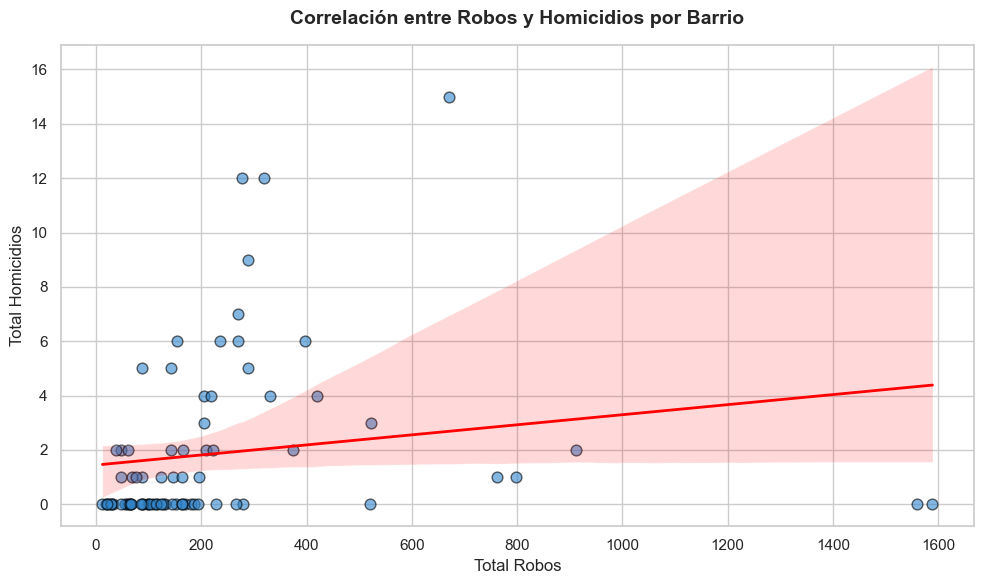

In [4]:
# Utilice este espacio para escribir el código.

#### 1. Gráfica de dispersión: total de homicidios y robos por área comunitaria

### a. Creamos un nuevo DataFrame sin la última fila de la tabla descriptiva
df_grafica = tabla_final[tabla_final['community'] != 'TOTAL CIUDAD'].copy()

## Convertimos las columnas de total_robos y total_homicidios a tipo numérico
df_grafica['total_homicidios'] = pd.to_numeric(df_grafica['total_homicidios'])

df_grafica['total_robos'] = pd.to_numeric(df_grafica['total_robos'])

### b. Creando el gráfico de dispersión (con la línea de regresión) con la librería Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.regplot(
    data = df_grafica, 
    x = 'total_robos', 
    y='total_homicidios',
    scatter_kws = {'alpha': 0.6, 'color': '#3186cc', 's': 60, 'edgecolor': 'black'}, 
    line_kws = {'color': 'red', 'linewidth': 2} 
)

plt.title('Correlación entre Robos y Homicidios por Barrio', 
          fontsize = 14, 
          weight = 'bold', 
          pad = 15)
plt.xlabel('Total Robos', 
           fontsize = 12)
plt.ylabel('Total Homicidios', 
           fontsize = 12)

# Ajustamos márgenes y mostramos
plt.tight_layout()
plt.show()


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

**Descripción del código:** creamos un nuevo DataFrame (*df_grafica*), en el que retiramos la última fila que contiene los datos agregados para la ciudad de Chicago y convertimos las columnas de *total_robos* y *total_homicidios* a tipo numérico.

**Gráfico de dispersión:** la gráfica muestra una relación lineal entre los homicidios y robos, además de que la mayoría de barrios están por debajo de los 400 robos y 8 homicidios. Sin embargo, existen datos atípicos en los que hay un elevado múmero de robos (más de 1500), pero cero homicidios, y menos de 1000 robos pero con un total de 15 homicidios.

### 3. Distribución espacial del delito

#### 3.1 Distribución respecto al centro de la ciudad

Tomando como centro de la ciudad las coordenadas (-87.627800, 41.881998), estime funciones de densidad que muestren gráficamente el gradiente del total de robos, y homicidios, como función de la distancia al centro de la ciudad. Explique cómo midió las distancias incluyendo que medida de distancia utilizó. Para elegir el ancho de banda y la función de kernel más apropiados utilice validación cruzada usando todas las opciones posibles de kernel. Describa los resultados que obtiene.

Para los robos -> Kernel: exponential, Bandwidth: 0.10
Para los homicidios -> Kernel: exponential, Bandwidth: 0.51


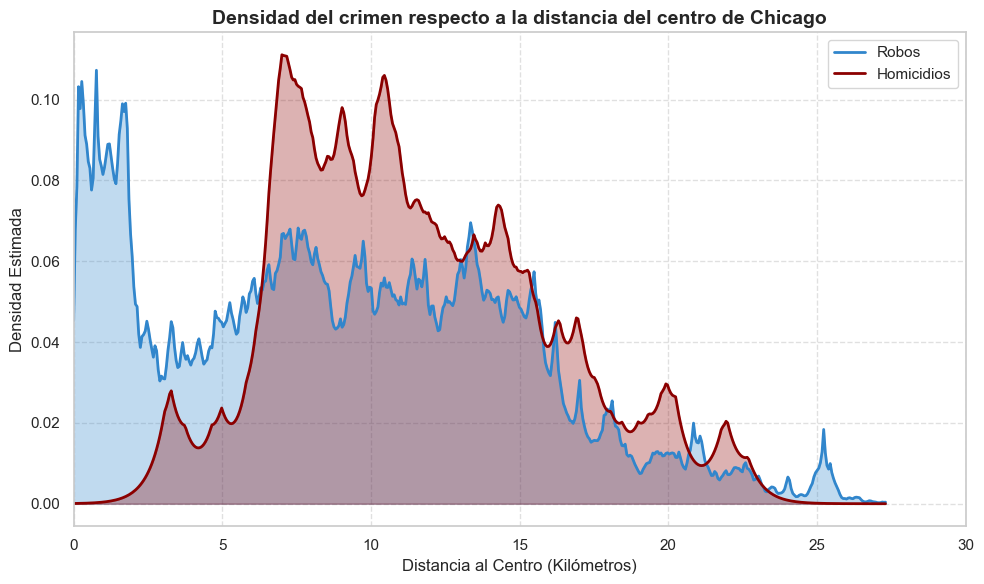

In [5]:
# Utilice este espacio para escribir el código.

#### 1. 
 
### a. Fijamos las coordenadas del centro de Chicago para el mapa
centro_lon, centro_lat = -87.627800, 41.881998

### b. Función para calcular la distancia de cada punto al centro geográfico de Chicago
def distancia_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0     
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])    
    dlat = lat2 - lat1
    dlon = lon2 - lon1    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

### c. Filtramos la base de datos para quedarnos solo con los delitos que tienen coordenadas geográficas
df_filtrado =df[(df['tipo_crimen'].isin(['robo', 'homicidio'])) &
                (df['lat'].notnull())].copy()

### d. Calculamos la distancia de cada crimen al centro geográfico de Chicago
df_filtrado['distancia_centro'] = distancia_haversine(
    df_filtrado['lat'], 
    df_filtrado['lon'],
    centro_lat, centro_lon
)

### e. Aplicamos Validación Cruzada para encontrar el mejor ancho de banda para el modelo KDE

## Probamos 15 anchos de banda entre 0.1 y 3 kilometros
parameters = {
    'bandwidth': np.linspace(0.1, 3.0, 15),
    'kernel': ['gaussian', 'tophat', 'epanechnikov', 
               'exponential', 'linear', 'cosine']
}

### f. Separamos los datos de las distancias de robos y homicidios
distancias_robos = df_filtrado[df_filtrado['tipo_crimen'] == 'robo']['distancia_centro'].values.reshape(-1, 1)
distancias_homicidios = df_filtrado[df_filtrado['tipo_crimen'] == 'homicidio']['distancia_centro'].values.reshape(-1, 1)

### g. Validación Cruzada para robos
grid_robos = GridSearchCV(KernelDensity(), 
                          parameters, 
                          cv = 5, 
                          n_jobs = -1)

grid_robos.fit(distancias_robos)

### h. Validación Cruzada para homicidios
grid_homicidios = GridSearchCV(KernelDensity(), 
                               parameters, 
                               cv = 5, 
                               n_jobs = -1)

grid_homicidios.fit(distancias_homicidios)

### i. Extraemos los mejores parámetros para cada modelo
kde_robos_optimo = grid_robos.best_estimator_
kde_homicidios_optimo = grid_homicidios.best_estimator_

### j. Mejores parámetros encontrados
print(f"Para los robos -> Kernel: {grid_robos.best_params_['kernel']}, Bandwidth: {grid_robos.best_params_['bandwidth']:.2f}")
print(f"Para los homicidios -> Kernel: {grid_homicidios.best_params_['kernel']}, Bandwidth: {grid_homicidios.best_params_['bandwidth']:.2f}")

### k. Creamos un eje ficticio para graficar las densidades de los robos y homicidios
x_plot = np.linspace(0, df_filtrado['distancia_centro'].max(), 500)[:, np.newaxis]

### l. Calculamos las densidades de los robos y homicidios usando los modelos KDE con los mejores parámetros
densidad_robos = np.exp(kde_robos_optimo.score_samples(x_plot))
densidad_homicidios = np.exp(kde_homicidios_optimo.score_samples(x_plot))

### m. Graficamos las densidades de robos y homicidios
plt.figure(figsize = (10, 6))
plt.plot(x_plot[:, 0], densidad_robos, 
         color = '#3186cc', 
         lw = 2, 
         label = 'Robos')
plt.fill_between(x_plot[:, 0], 
                 densidad_robos, 
                 alpha = 0.3, 
                 color = '#3186cc')

plt.plot(x_plot[:, 0], 
         densidad_homicidios, 
         color = 'darkred', 
         lw = 2, 
         label = 'Homicidios')
plt.fill_between(x_plot[:, 0], 
                 densidad_homicidios, 
                 alpha = 0.3, 
                 color = 'darkred')

plt.title('Densidad del crimen respecto a la distancia del centro de Chicago', 
          fontsize = 14, 
          weight = 'bold')
plt.xlabel('Distancia al Centro (Kilómetros)', 
           fontsize = 12)
plt.ylabel('Densidad Estimada', 
           fontsize = 12)
plt.legend()
plt.xlim(0, 30) 
plt.grid(True, 
         linestyle = '--', 
         alpha = 0.6)
plt.tight_layout()
plt.show()


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

**Descripción del código:** iniciamos con la fijación de las coordenadas de longitud y latitud en los objetos *centro_lon* y *centro_lat*.La distancia de Haversine nos permite aproximar la distancia de círculo máximo sobre una superficie esférica. Para implementar la **Densidad de Kernel (KDE)**, usamos una Validación Cruzada (VC) que tiene como objetivo evitar problemas con sobreajuste o subajuste del modelo KDE, para esto se implementó una malla que evalúa valores (kilómetros) entre 0.1 y 3 junto a todos los kernel disponibles (Gaussian, Tophat, Epanechnikov, etc). 

**Gráfica de densidades** la gráfica muestra que los robos (color azul) se concentran en el centro de la ciudad de Chicago, tiene una fuerte caída a los tres kilómetros, además la densidad de los homicidios (color rojo) presenta un pico a los 7 KM del centro. Todo lo anterior está representando que los homicidios, y parte de los robos, tienden a concentrarse entre los 7 y 15 KM del centro de Chicago.

### 3.2 Puntos calientes en la ciudad

Usando `statsmodels` implemente la estimación de densidad bivariada para el total de robos y el total de homicidios. Muestre los resultados usando curvas de nivel en una visualización interactiva. Compare los resultados de estimar usando los anchos de banda: `normal_reference` y `cv_ml`. Explique en que consisten ambas formas de estimar el ancho de banda. Comente sobre los puntos calientes encontrados bajo ambos métodos y su ubicación en la ciudad. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [6]:
# Utilice este espacio para escribir el código.

#### 1. Estimación de densidad bivariada para el total de robos y homicidios

### a. Eliminamos los posibles datos vacíos en las columnas de latitud y longitud
df_clean = df.dropna(subset = ['lat', 'lon'])

### b. Separamos las coordenadas de los homicidios y robos de la base de datos limpia
robos_coords = df_clean[df_clean['tipo_crimen'] == 'robo'][['lon', 'lat']]
hom_coords = df_clean[df_clean['tipo_crimen'] == 'homicidio'][['lon', 'lat']]

### c. Tomamos una muestra aleatoria de 500 puntos para que la VC sea menos demorada
n_sample = 500

coords_robos = robos_coords.sample(n = min(n_sample, len(robos_coords)), 
                                   random_state = 42).values

coords_homicidios = hom_coords.sample(n = min(n_sample, len(hom_coords)), 
                                      random_state = 42).values

### d. Estimamos la densidad bivariada para robos y homicidios

## Densidad bivariada de los robos
kde_robos_nr = sm.nonparametric.KDEMultivariate(data = coords_robos, 
                                                var_type = 'cc', 
                                                bw = 'normal_reference')

kde_robos_cv = sm.nonparametric.KDEMultivariate(data = coords_robos, 
                                                var_type = 'cc', 
                                                bw = 'cv_ml')

## Densidad bivariada de los homicidios
kde_hom_nr = sm.nonparametric.KDEMultivariate(data = coords_homicidios, 
                                              var_type = 'cc', 
                                              bw = 'normal_reference')

kde_hom_cv = sm.nonparametric.KDEMultivariate(data = coords_homicidios, 
                                              var_type = 'cc', 
                                              bw = 'cv_ml')

### e. Fijamos los límites geográficos de Chicago
lon_min, lon_max = -87.95, -87.50
lat_min, lat_max = 41.60, 42.05

### f. Creamos una malla para evaluar las densidades
X, Y = np.mgrid[lon_min:lon_max:100j, lat_min:lat_max:100j]
posiciones = np.vstack([X.ravel(), Y.ravel()]).T

### g. Evaluando la densidad del modelo sobre la malla
Z_robos_nr = kde_robos_nr.pdf(posiciones).reshape(100, 100)
Z_robos_cv = kde_robos_cv.pdf(posiciones).reshape(100, 100)
Z_hom_nr = kde_hom_nr.pdf(posiciones).reshape(100, 100)
Z_hom_cv = kde_hom_cv.pdf(posiciones).reshape(100, 100)

### h. Función para transformar las curvas a imágenes Base64
def exportar_kde_base64(X, Y, Z, mapa_colores):
    fig, ax = plt.subplots(figsize = (8, 8))
    ax.set_axis_off() 
    fig.patch.set_alpha(0.0) 
    ax.patch.set_alpha(0.0)    
    
    ax.contourf(X, Y, Z, levels = 10, 
                cmap = mapa_colores, 
                alpha = 0.6)    
    
    buf = io.BytesIO()
    plt.savefig(buf, format = 'png', 
                bbox_inches = 'tight', 
                pad_inches = 0, 
                transparent = True)
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return img_b64

### i. Generando los componentes de imagen con paleta crimática diferenciada
img_robos_nr = exportar_kde_base64(X, Y, Z_robos_nr, 'Blues')
img_robos_cv = exportar_kde_base64(X, Y, Z_robos_cv, 'YlOrBr')
img_hom_nr   = exportar_kde_base64(X, Y, Z_hom_nr, 'Purples')
img_hom_cv   = exportar_kde_base64(X, Y, Z_hom_cv, 'Reds')


### j. Creamos el mapa con base en el centro de Chicago
mapa_kde = folium.Map(location = [41.8781, -87.6298], 
                      zoom_start = 10, 
                      tiles = 'OpenStreetMap')

### k. Agregamos las 4 capas al mapa
folium.raster_layers.ImageOverlay(
    image=f'data:image/png;base64,{img_robos_nr}',
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.6, name='Robos - Normal Reference', show=False
).add_to(mapa_kde)

folium.raster_layers.ImageOverlay(
    image=f'data:image/png;base64,{img_robos_cv}',
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.6, name='Robos - CV ML', show=True
).add_to(mapa_kde)

folium.raster_layers.ImageOverlay(
    image=f'data:image/png;base64,{img_hom_nr}',
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.6, name='Homicidios - Normal Reference', show=False
).add_to(mapa_kde)

folium.raster_layers.ImageOverlay(
    image=f'data:image/png;base64,{img_hom_cv}',
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.6, name='Homicidios - CV ML', show=False
).add_to(mapa_kde)

### l. Alternamos las capas de robos y homicidios en el cuaderno de Jupyter
folium.LayerControl().add_to(mapa_kde)

### m. Mostramos el mapa interactivo
mapa_kde.save("mapa_chicago_kde.html")

IFrame(src="mapa_chicago_kde.html", 
       width = "100%", 
       height = "600px")

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

**Descripción del código:** iniciamos con la limpieza de los datos vacíos (NaNs), separando las coordenadas para homicidios y robos, tomamos una muestra aleatoria de 500 puntos de los delitos anteriormente descritos, para evitar que la Validaación Cruzada (VC) colapse la memoria RAM del computador. Hacemos la estimación de de la densidad bivariada de los anchos de banda con *normal_reference* (se asume a priori que la distribución de los datos es aproximadamente normal) y *cv_ml* (utiliza un proceso iterativo en el que el algoritmo oculta el delito y adivina su ubicación usando el resto de puntos con un determinado ancho de banda calculando la verosimilitud, luego repite este proceso hasta para miles de bandas hasta encontrar el que maximice la probabilidad de predecir la realidad). 

Fijamos las coordenadas de los límites geográficos de la ciudad de Chicago, evaluamos la densidad del modelo sobre la malla y generamos el mapa interactivo.

**Análisis del Mapa:**

  - *Robos de Normal-Reference:* el primer mapa tiene un color azul que muestra como centro la región de Near North Side, de lo cual inferimos que en la región central de Chicago concentra los robos y que se extienden difusamente a través de la ciudad.  
  - *Homicidios de Normal-Reference:* acá hay dos puntos centrales, el primero está en el West Carfield Park que tiene el color violeta más fuerte lo que implica una mayor concentración de homicidios, y en segundo lugar está el punto en Becks Park.
  - *Robos de CV-ML:* los robos tienen como punto central en el Vietnam Veterans Fountain, el color amarillo se expande a través de la ciudad.
  - *Homicidios de CV-ML:* el principal punto de homicidios está en el Garfield Park, sin embargo, hay otros puntos pequeños a través de la ciudad como Roseland o West 68th Street.

## 4. Explicando la ubicación del delito

El objetivo de este punto es encontrar posibles correlaciones  entre el crimen y características de la ciudad. Para ello, utilice los datos de OpenStreetMap y explore si existe una correlación entre el porcentaje del área de la comunidad  dedicado a tiendas (`retail`)  y comercios (`commercial`) y el número total de robos y homicidios en esa comunidad. Ofrezca una explicación intuitiva de por qué cree que aparecen estas correlaciones. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

Coeficiente de correlación con Robos: 0.6955
Coeficiente de correlación con Homicidios: -0.2468


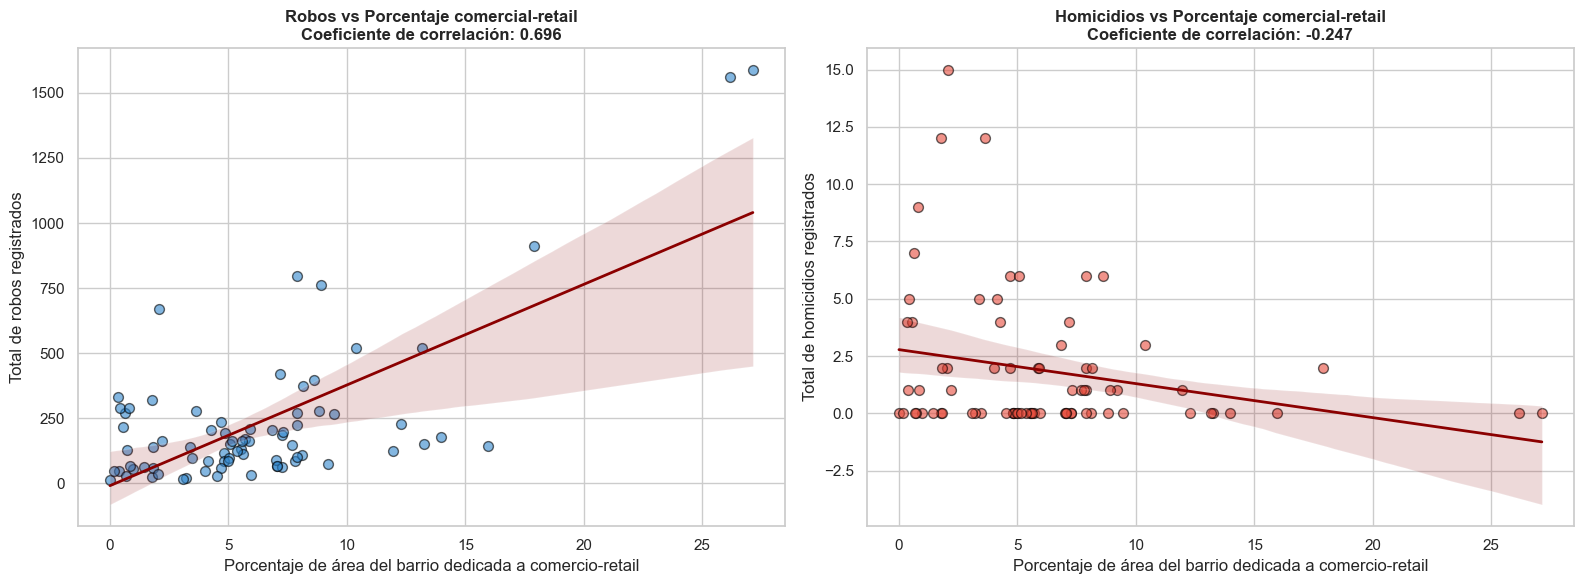

In [7]:
# Utilice este espacio para escribir el código.

#### 1. Correlaciones entre el crimen y las características de Chicago como tiendas (retail) y comercios (commercial)

### a. Transformamos el DataFrame de las áreas comunitarias a un sistema de coordenadas en metros cuadrados
df_areas_m = df_areas.to_crs(epsg = 3435)

### b. Añadimos la columna con el área de cada barrio en metros cuadrados
df_areas_m['area_total_m2'] = df_areas_m.geometry.area

### c. Descargamos los datos de los retail y comercios desde OpenStreetMaps

## Fijamos las etiquetas de uso de suelos
tags = {'landuse': ['retail', 
                    'commercial']}

## Frontera unificada de Chicago
frontera_chicago = df_areas.to_crs(epsg = 4326).unary_union

## Descargando las características geométricas 
osm_features = ox.features_from_polygon(frontera_chicago, 
                                        tags = tags)

## Proyectamos las geometrías de OSM al mismo CRS métrico loca
osm_features_m = osm_features.to_crs(epsg = 3435)

## Filtramos únicamente los polígnonos (en lugar de los multipolígonos)
osm_features_m = osm_features_m[osm_features_m.geom_type.isin(['Polygon', 
                                                               'MultiPolygon'])]

### d. Cortamos los polígonos comerciales con los límites de cada barrio
interseccion = gpd.overlay(osm_features_m, 
                           df_areas_m, 
                           how = 'intersection')

interseccion['area_comercial_m2'] = interseccion.geometry.area

### e. Agrupando por identificador único de cada barrio para sumar el área comercial dentro de cada uno
area_comercial_barrio = interseccion.groupby('community')['area_comercial_m2'].sum().reset_index()

### f. Unimos los resultados con la tabla base de las áreas comunitarias
df_morfologico = df_areas_m[['community', 'area_total_m2']].merge(
    area_comercial_barrio, 
    on = 'community', 
    how = 'left'
)

### g. Rellenamos con cero los barrios que no registran comercio
df_morfologico['area_comercial_m2'] = df_morfologico['area_comercial_m2'].fillna(0)

### h. Calculando el porcentaje del área total del barrio que corresponde a comercio
df_morfologico['perc_comercial_retail'] = (df_morfologico['area_comercial_m2'] / df_morfologico['area_total_m2']) * 100

### i. Tomamos la tabla descriptiva y retiramos la última fila
df_crimen_analisis = tabla_final[tabla_final['community'] != 'TOTAL CIUDAD'].copy()

### j. Hacemos una unión, con merge, entre la tabla descriptiva y el DataFrame con las características morfológicas de los barrios
df_final = df_morfologico.merge(df_crimen_analisis, 
                                on = 'community', 
                                how = 'inner')

### k. Calculamos las correlaciones entre el porcentaje de comercio y retail con el total de robos y homicidios por barrio
corr_robos = df_final['perc_comercial_retail'].corr(df_final['total_robos'])
corr_homicidios = df_final['perc_comercial_retail'].corr(df_final['total_homicidios'])

print(f"Coeficiente de correlación con Robos: {corr_robos:.4f}")
print(f"Coeficiente de correlación con Homicidios: {corr_homicidios:.4f}")

### l. 

fig, axes = plt.subplots(1, 2, figsize = (16, 6))
sns.set_theme(style = "whitegrid")

# Gráfica para Robos
sns.regplot(data=df_final, 
            x = 'perc_comercial_retail', 
            y = 'total_robos', ax = axes[0],
            scatter_kws = {'alpha':0.6, 
                           'color':'#3186cc', 
                           's':50, 'edgecolor':'black'},
            line_kws={'color':'darkred', 'linewidth':2})
axes[0].set_title(f'Robos vs Porcentaje comercial-retail\nCoeficiente de correlación: {corr_robos:.3f}', 
                  fontsize = 12, 
                  weight = 'bold')
axes[0].set_xlabel('Porcentaje de área del barrio dedicada a comercio-retail')
axes[0].set_ylabel('Total de robos registrados')

# Gráfica para Homicidios
sns.regplot(data=df_final, 
            x = 'perc_comercial_retail', 
            y = 'total_homicidios', 
            ax = axes[1],
            scatter_kws={'alpha':0.6, 
                         'color':'#e74c3c', 
                         's':50, 
                         'edgecolor':'black'},
            line_kws={'color':'darkred', 'linewidth':2})
axes[1].set_title(f'Homicidios vs Porcentaje comercial-retail\nCoeficiente de correlación: {corr_homicidios:.3f}', 
                  fontsize = 12, 
                  weight = 'bold')
axes[1].set_xlabel('Porcentaje de área del barrio dedicada a comercio-retail')
axes[1].set_ylabel('Total de homicidios registrados')

plt.tight_layout()
plt.show()


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

**Descripción del código:** para evaluar las correlaciones espaciales entre los barrios con áreas (metros cuadrados) dedicados a comercio o locales de venta de comida, es necesario hacer una transformación del sistema de coordenadas local para el estado de Illinios (3435) y con la función de la librería GeoPandas *gpd.overlay(how='intersection')* que determina las hectáreas netas de suelo dedicadas a comercio o retail extraídas desde Open Street Map. 

**Análisis de las gráficas:** la primera gráfica (izquierda) nos muestra una correlación positiva, tendencia ascendente, entre el número de robos registrados y el porcentaje de área del barrio dedicada a comercio o retail. Esto puede tener origen en que los robos se presentan en áreas urbanas en las que hay presencia de locales comerciales con aglomeración de consumidores.

La gráfica de homicidios presenta una correlación negativa con una elevada presencia de datos atípicos, es posible concluir que los homicidios no está conectada con la actividad comercial y ocurre principalmente en áreas residenciales con poca presencia de locales comerciales (es posible que correspondan a Food-Desert).